<a href="https://colab.research.google.com/github/manshatanwar/DPIIT-Startup-Impact-Analysis/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import zipfile
import os

zip_file_path = '/content/gov-data-final.csv'
extraction_dir = '/gov-data-final.csv'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

# Decompress the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"File '{zip_file_path}' decompressed to '{extraction_dir}'")

# List the contents of the extracted directory
print("Contents of the extracted directory:")
for item in os.listdir(extraction_dir):
    print(item)

File '/content/gov-data-final.csv' decompressed to '/gov-data-final.csv'
Contents of the extracted directory:
docProps
_rels
xl
[Content_Types].xml


In [35]:
df_startups = pd.read_excel('/content/gov-data-final.csv')
df_jobs = pd.read_csv('/content/startup-jobs-data.csv')

In [36]:
for df in [df_startups, df_jobs]:
  df.columns= df.columns.str.strip()
  if 'State/UT' in df.columns:
    df.rename(columns={'State/UT': 'State'}, inplace=True)
  df['State']= df['State'].str.title()
  if 'Industry' in df.columns:
    df['Industry']= df['Industry'].str.title()

In [39]:
df_jobs.rename(columns={'2024': 'Jobs created in 2024 '}, inplace=True)



In [51]:
state_startup_totals = df_startups.groupby('State')['Count'].sum().reset_index()
state_startup_totals.rename(columns={'Count': 'Total_Startups_2024'}, inplace=True)
print('State Startup Totals')
print(state_startup_totals)
jobs_2024 = df.loc[:,['State','Jobs created in 2024']].copy()
print( 'Jobs Created By Startups In Each State In 2024')
print(jobs_2024)

State Startup Totals
                                       State  Total_Startups_2024
0                Andaman And Nicobar Islands                   89
1                             Andhra Pradesh                 3887
2                          Arunachal Pradesh                   85
3                                      Assam                 2014
4                                      Bihar                 4565
5                                 Chandigarh                  660
6                               Chhattisgarh                 2245
7   Dadra And Nagar Haveli And Daman And Diu                   89
8                                      Delhi                19914
9                                        Goa                  773
10                                   Gujarat                17692
11                                   Haryana                10744
12                          Himachal Pradesh                  762
13                         Jammu And Kashmir           

In [47]:
df_efficiency = pd.merge(state_startup_totals, jobs_2024, on='State', how='inner')
df_efficiency['Job_Density'] = df_efficiency['Jobs created in 2024'] / df_efficiency['Total_Startups_2024']
print( 'Efficiency',df_efficiency)


Efficiency                                        State  Total_Startups_2024  \
0                Andaman And Nicobar Islands                   89   
1                             Andhra Pradesh                 3887   
2                          Arunachal Pradesh                   85   
3                                      Assam                 2014   
4                                      Bihar                 4565   
5                                 Chandigarh                  660   
6                               Chhattisgarh                 2245   
7   Dadra And Nagar Haveli And Daman And Diu                   89   
8                                      Delhi                19914   
9                                        Goa                  773   
10                                   Gujarat                17692   
11                                   Haryana                10744   
12                          Himachal Pradesh                  762   
13                     

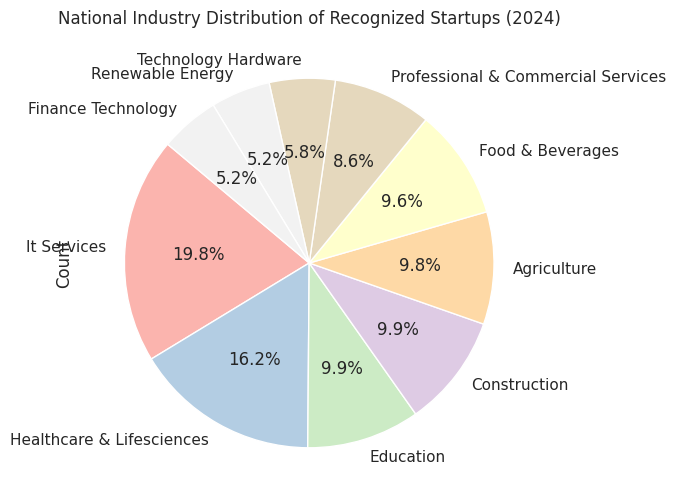

In [44]:
plt.figure(figsize=(12, 6))
industry_mix = df_startups.groupby('Industry')['Count'].sum().sort_values(ascending=False).head(10)
industry_mix.plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1', startangle=140)
plt.title('National Industry Distribution of Recognized Startups (2024)')
plt.show()

In [ ]:
India has successfully diversified its innovation core into Healthcare & Lifesciences (16.2%), Education (9.9%), and Construction (9.9%).The high presence of Renewable Energy (5.2%) and Finance Technology (5.2%) startups indicates that policy-driven sectors are gaining significant ground.

/tmp/ipykernel_226/1374519795.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(ax=axes[0], data=df_jobs, estimator='sum', ci=None, marker='o', color='#2ecc71')
/tmp/ipykernel_226/1374519795.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=top_density, x='Job_Density', y='State', palette='mako')


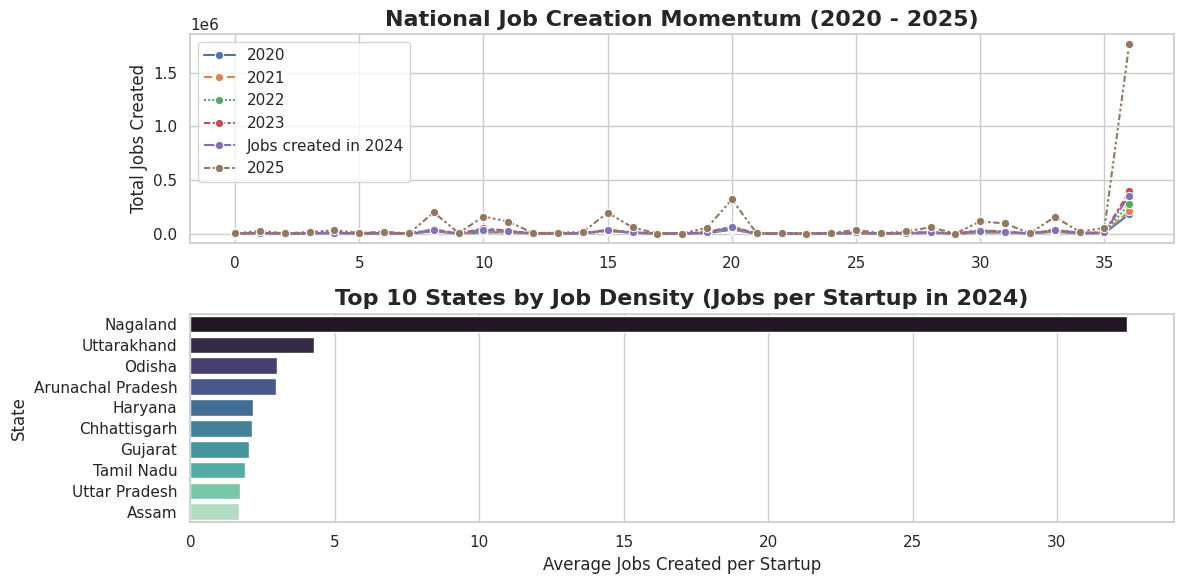

In [46]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
sns.lineplot(ax=axes[0], data=df_jobs, estimator='sum', ci=None, marker='o', color='#2ecc71')
axes[0].set_title('National Job Creation Momentum (2020 - 2025)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Total Jobs Created')
top_density = df_efficiency.sort_values('Job_Density', ascending=False).head(10)
sns.barplot(ax=axes[1], data=top_density, x='Job_Density', y='State', palette='mako')
axes[1].set_title('Top 10 States by Job Density (Jobs per Startup in 2024)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Average Jobs Created per Startup')

plt.tight_layout()
plt.show()

Between 2020 and 2023, the ecosystem was in a "Volume Phase" (focusing on the number of startups). By 2025, we entered the "Value Phase" where existing startups began scaling their operations.The job density suggests that while metro hubs have more startups by volume, North-Eastern states and Himalayan states (like Uttarakhand) are hosting highly "job-intensive" ventures, likely in specialized sectors like agri-processing or sustainable tourism.